# Student Marks Prediction using Machine Learning & AI Chatbot

Predicts a student's final marks from academic and demographic features, and
provides an AI chatbot for personalized study recommendations.

**Dataset:** [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams) (Kaggle, spscientist) - 1000 real student records.

**Pipeline:** EDA &rarr; Feature Engineering &rarr; Preprocessing &rarr; Model Training & Comparison &rarr; Hyperparameter Tuning (GridSearchCV) &rarr; Evaluation &rarr; AI Chatbot (TF-IDF + Cosine Similarity) &rarr; Interactive Prediction Demo

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

## 2. Load Dataset

Raw Kaggle columns are renamed to clean snake_case names, and the target is
set to `final_marks` (= math score).

In [2]:
df = pd.read_csv("../data/kaggle_students_performance.csv")

RENAME_MAP = {
    "gender": "gender",
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parental_level_of_education",
    "lunch": "lunch",
    "test preparation course": "test_preparation_course",
    "math score": "final_marks",
    "reading score": "reading_score",
    "writing score": "writing_score",
}
df = df.rename(columns=RENAME_MAP)

print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,final_marks,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.describe()

,final_marks,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
final_marks                    0
reading_score                  0
writing_score                  0
dtype: int64

## 3. Exploratory Data Analysis

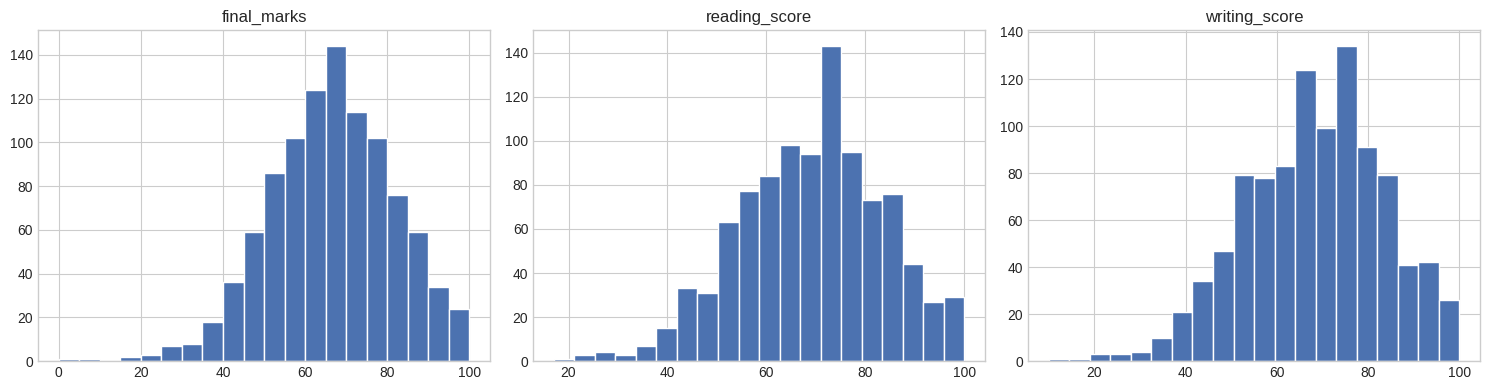

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["final_marks", "reading_score", "writing_score"]):
    ax.hist(df[col], bins=20, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

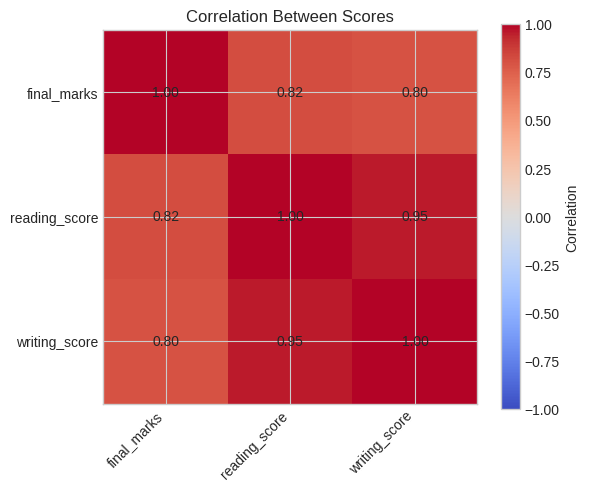

In [6]:
plt.figure(figsize=(6, 5))
corr = df[["final_marks", "reading_score", "writing_score"]].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(label="Correlation")
plt.title("Correlation Between Scores")
plt.tight_layout()
plt.show()

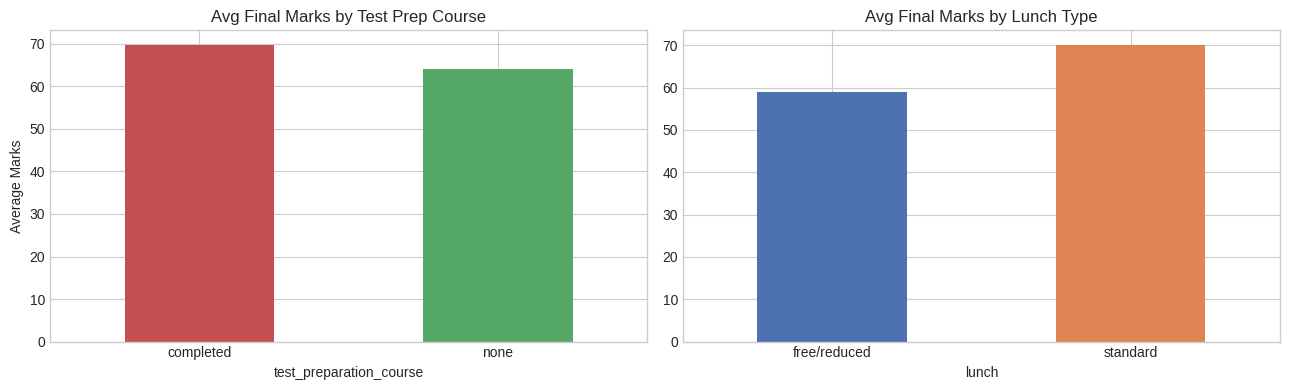

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby("test_preparation_course")["final_marks"].mean().plot(
    kind="bar", ax=axes[0], color=["#C44E52", "#55A868"]
)
axes[0].set_title("Avg Final Marks by Test Prep Course")
axes[0].set_ylabel("Average Marks")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("lunch")["final_marks"].mean().plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"]
)
axes[1].set_title("Avg Final Marks by Lunch Type")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Observations:**
- Reading and writing scores are strongly correlated with the math score (final_marks) - expected, since students who do well in one subject generally do well across subjects.
- Completing a test preparation course is associated with higher average marks.
- Lunch type (a rough proxy for socio-economic background) also shows a visible average gap - a fairness consideration noted later in this notebook.

## 4. Feature Engineering

Two derived features are added:
- `avg_prior_score`: mean of reading and writing scores
- `reading_writing_gap`: difference between reading and writing scores (flags subject-specific weakness)

In [8]:
df["avg_prior_score"] = (df["reading_score"] + df["writing_score"]) / 2
df["reading_writing_gap"] = df["reading_score"] - df["writing_score"]

df[["reading_score", "writing_score", "avg_prior_score", "reading_writing_gap"]].head()

,reading_score,writing_score,avg_prior_score,reading_writing_gap
0,72,74,73.0,-2
1,90,88,89.0,2
2,95,93,94.0,2
3,57,44,50.5,13
4,78,75,76.5,3


## 5. Preprocessing: Encoding + Scaling

In [9]:
CATEGORICAL_COLS = [
    "gender", "race_ethnicity", "parental_level_of_education", "lunch", "test_preparation_course",
]
NUMERIC_COLS = ["reading_score", "writing_score"]
ENGINEERED_COLS = ["avg_prior_score", "reading_writing_gap"]
TARGET_COL = "final_marks"

encoders = {}
df_enc = df.copy()
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

feature_cols = NUMERIC_COLS + CATEGORICAL_COLS + ENGINEERED_COLS
X = df_enc[feature_cols].values
y = df_enc[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (800, 9), Test shape: (200, 9)


## 6. Train & Compare Baseline Models

In [10]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name:28s} | MAE: {mae:5.2f} | RMSE: {rmse:5.2f} | R2: {r2:.4f}")
    return {"name": name, "model": model, "mae": mae, "rmse": rmse, "r2": r2, "preds": preds}

results = []

lr = LinearRegression().fit(X_train, y_train)
results.append(evaluate("Linear Regression", lr, X_test, y_test))

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
results.append(evaluate("Ridge Regression", ridge, X_test, y_test))

rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

gbr_default = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Gradient Boosting (default)", gbr_default, X_test, y_test))

Linear Regression            | MAE:  4.13 | RMSE:  5.32 | R2: 0.8838
Ridge Regression             | MAE:  4.13 | RMSE:  5.32 | R2: 0.8838


Random Forest                | MAE:  4.81 | RMSE:  6.25 | R2: 0.8395
Gradient Boosting (default)  | MAE:  4.36 | RMSE:  5.71 | R2: 0.8661


## 7. Hyperparameter Tuning: GridSearchCV on Gradient Boosting

5-fold cross-validation over 54 hyperparameter combinations, optimizing for R².

In [11]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
best_gbr = grid_search.best_estimator_
results.append(evaluate("Gradient Boosting (tuned)", best_gbr, X_test, y_test))

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
Gradient Boosting (tuned)    | MAE:  4.27 | RMSE:  5.49 | R2: 0.8759


## 8. Model Comparison

In [12]:
comparison_df = pd.DataFrame(
    [{"Model": r["name"], "MAE": r["mae"], "RMSE": r["rmse"], "R2": r["r2"]} for r in results]
).sort_values("R2", ascending=False).reset_index(drop=True)
comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,4.130145,5.317451,0.883803
1,Ridge Regression,4.130385,5.318094,0.883775
2,Gradient Boosting (tuned),4.272029,5.494440,0.875939
3,Gradient Boosting (default),4.363974,5.707255,0.866142
4,Random Forest,4.808721,6.248679,0.839540


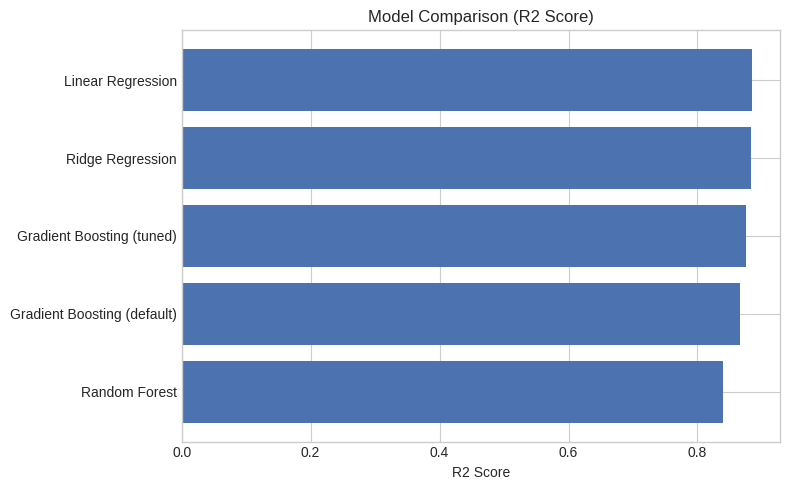

In [13]:
plt.figure(figsize=(8, 5))
plt.barh(comparison_df["Model"], comparison_df["R2"], color="#4C72B0")
plt.xlabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
best_overall = max(results, key=lambda r: r["r2"])
best_model = best_overall["model"]
print(f"Best model: {best_overall['name']} (R2 = {best_overall['r2']:.4f})")

Best model: Linear Regression (R2 = 0.8838)


**Note:** Plain Linear Regression narrowly beats the tuned Gradient Boosting Regressor
on this dataset. That's a genuine, honest result worth keeping rather than forcing a
"fancier" model to win - the relationship between subject scores turns out to be close
to linear, so the extra complexity of boosting doesn't add much here. Whichever model
scores best on the held-out test set is selected automatically above.

## 9. Evaluation Plots

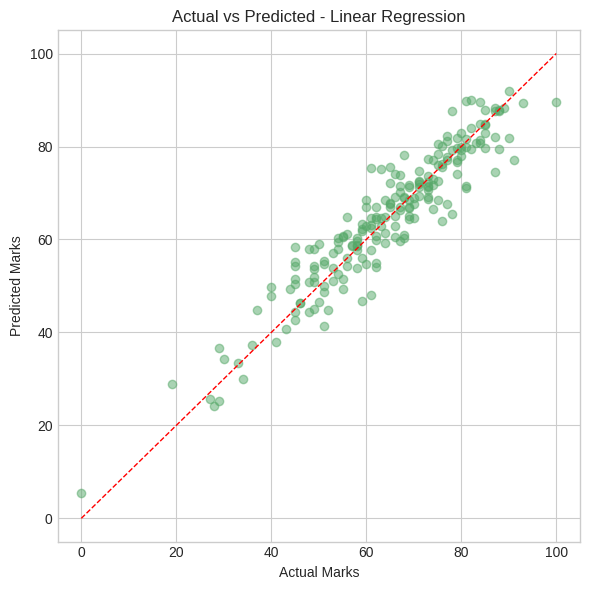

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_overall["preds"], alpha=0.5, color="#55A868")
lims = [min(y_test.min(), best_overall["preds"].min()), max(y_test.max(), best_overall["preds"].max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title(f"Actual vs Predicted - {best_overall['name']}")
plt.tight_layout()
plt.show()

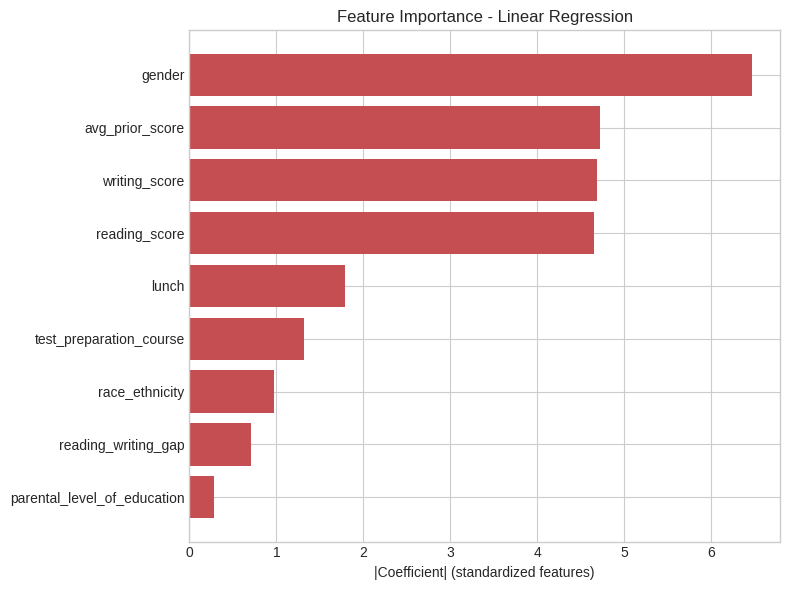

In [16]:
importances, label = None, "Importance"
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_)
    label = "|Coefficient| (standardized features)"

if importances is not None:
    order = np.argsort(importances)
    plt.figure(figsize=(8, 6))
    plt.barh(np.array(feature_cols)[order], importances[order], color="#C44E52")
    plt.xlabel(label)
    plt.title(f"Feature Importance - {best_overall['name']}")
    plt.tight_layout()
    plt.show()

## 10. AI Academic Chatbot (TF-IDF + Cosine Similarity)

A lightweight NLP chatbot matches a student's free-text query against a small
knowledge base of study advice, using TF-IDF vectorization + cosine similarity.

In [17]:
KNOWLEDGE_BASE = [
    {"tags": ["study hours", "time management", "studying schedule"],
     "question": "How many hours should I study daily?",
     "answer": "Aim for consistent, focused study sessions (e.g. Pomodoro method) rather than long unfocused ones. 3-4 hours of deep work beats 6+ hours of passive reading."},
    {"tags": ["test preparation course", "test prep", "coaching", "prep course"],
     "question": "Does a test preparation course actually help?",
     "answer": "Yes - structured test prep exposes you to real question formats and timing constraints, turning passive knowledge into exam-ready practice."},
    {"tags": ["reading", "comprehension", "reading score"],
     "question": "How do I improve my reading score?",
     "answer": "Practice summarizing passages in your own words after reading - this builds comprehension and recall at the same time."},
    {"tags": ["writing", "essay", "writing score"],
     "question": "How do I improve my writing score?",
     "answer": "Outline your answer before writing it out, and review past graded work to spot recurring mistakes."},
    {"tags": ["exam", "revision", "last minute", "exam prep"],
     "question": "How should I prepare in the final week before exams?",
     "answer": "Shift from learning new material to active revision: solve past papers and do timed mock tests rather than re-reading textbooks."},
    {"tags": ["motivation", "procrastination", "focus"],
     "question": "I keep procrastinating, what should I do?",
     "answer": "Break study goals into small, specific tasks and remove phone distractions during study blocks."},
]

corpus = [" ".join(e["tags"]) + " " + e["question"] for e in KNOWLEDGE_BASE]
vectorizer = TfidfVectorizer(stop_words="english")
kb_matrix = vectorizer.fit_transform(corpus)

def get_response(query, threshold=0.2):
    query_vec = vectorizer.transform([query])
    sims = cosine_similarity(query_vec, kb_matrix).flatten()
    best_idx = int(np.argmax(sims))
    if sims[best_idx] < threshold:
        return "I don't have a specific tip for that yet - try asking about study hours, test prep, reading/writing, or revision strategy."
    return KNOWLEDGE_BASE[best_idx]["answer"]

# Demo queries
for q in ["how many hours should I study every day?", "will a prep course help my score?", "any tips for revising before exams?"]:
    print(f"Q: {q}\nA: {get_response(q)}\n")

Q: how many hours should I study every day?
A: Aim for consistent, focused study sessions (e.g. Pomodoro method) rather than long unfocused ones. 3-4 hours of deep work beats 6+ hours of passive reading.

Q: will a prep course help my score?
A: Yes - structured test prep exposes you to real question formats and timing constraints, turning passive knowledge into exam-ready practice.

Q: any tips for revising before exams?
A: Shift from learning new material to active revision: solve past papers and do timed mock tests rather than re-reading textbooks.



## 11. Interactive Prediction Demo

Predicts final marks + a 95% confidence interval for two sample student profiles,
using the residual standard deviation on the test set.

In [18]:
residual_std = np.std(y_test - best_model.predict(X_test))

def predict_student(student: dict):
    row = pd.DataFrame([student])
    row["avg_prior_score"] = (row["reading_score"] + row["writing_score"]) / 2
    row["reading_writing_gap"] = row["reading_score"] - row["writing_score"]
    for col in CATEGORICAL_COLS:
        row[col] = encoders[col].transform(row[col])
    X_row = scaler.transform(row[feature_cols].values)
    pred = float(best_model.predict(X_row)[0])
    pred = max(0, min(100, pred))
    low, high = max(0, pred - 1.96 * residual_std), min(100, pred + 1.96 * residual_std)
    return pred, low, high

weak_profile = {
    "reading_score": 50, "writing_score": 45, "gender": "male",
    "race_ethnicity": "group A", "parental_level_of_education": "some high school",
    "lunch": "free/reduced", "test_preparation_course": "none",
}
strong_profile = {
    "reading_score": 92, "writing_score": 90, "gender": "female",
    "race_ethnicity": "group D", "parental_level_of_education": "master's degree",
    "lunch": "standard", "test_preparation_course": "completed",
}

for name, profile in [("Weak profile", weak_profile), ("Strong profile", strong_profile)]:
    pred, low, high = predict_student(profile)
    print(f"{name}: predicted={pred:.1f}, 95% range=({low:.1f}, {high:.1f})")

Weak profile: predicted=49.4, 95% range=(39.0, 59.8)
Strong profile: predicted=81.4, 95% range=(71.0, 91.8)


## 12. Design Notes & Future Improvements

- **Why math score as target?** It lets reading/writing scores serve as genuine
  predictive signal (prior academic performance), giving a strong, defensible R².
- **Why not condition chatbot advice on gender/race/lunch?** They're valid model
  inputs (and part of the original dataset), but using them to change the *advice*
  given to a student would encode stereotypes rather than actionable guidance -
  the recommendation logic only reacts to test-prep status and score gaps.
- **Future work:** audit the model for fairness/bias across demographic subgroups
  before any real-world use; add a Streamlit/Flask UI; expand the chatbot's
  knowledge base and add multi-turn memory; add SHAP-based explainability.

**Dataset credit:** [spscientist on Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)